# Supplementary Figure S9: `s09_axis_alignment_stats`

This notebook rebuilds the figure step by step from its script, `figures/supplementary/sup_axis_alignment_stats.py`. Every code cell below is a verbatim slice of that file, in the order the file defines it: first the imports and configuration, then each helper function with a short explanation, then the body of `main()` laid out as the assembly of the panels, and finally the rendered figure with its caption. Run the cells top to bottom; in the reference environment the PNG written at the end is identical to the submitted manuscript file (see docs/REPRODUCIBILITY.md).

Supplementary Figure S9 asks whether an accentuation sweep moves the image along the site's encoding axis or mostly sideways in feature space. Each sweep's net displacement in the 750-dimensional PCA feature space is split into an on-axis component along the fitted encoding axis (DM) and an off-axis residual pooled over the remaining 749 dimensions (DOM). Panel a is a toy schematic of the decomposition; panel b is the distribution over sweeps of the per-dimension ratio DM / (DOM / sqrt(749)); panel c compares the on-axis displacement to the sorted spectrum of off-axis displacements; panel d breaks the ratio out by model. All quantities come precomputed from `loader.load_axis_alignment()`.

## What the script says about itself

Supp fig (axis_alignment_stats) - encoding-axis alignment of accentuation sweeps.

On-axis / off-axis decomposition of each sweep's net latent displacement in the 750-d PCA feature space: DM  = |d . a^|            displacement along the encoding axis DOM = ||d - (d.a^) a^||   off-axis residual (over the other 749 dims)

Raw DM:DOM is < 1 only because DOM pools 749 dimensions. Per representational dimension the encoding axis dominates: DM : (DOM/sqrt(749)) ~ 15x, and the encoding axis is the single most-modulated dimension in ~87% of sweeps.

Panels: a  schematic of the on-/off-axis decomposition (fake latent space) b  per-sweep distribution of the per-dimension ratio DM/(DOM/sqrt(749)) c  population displacement spectrum (encoding axis vs sorted off-axis dims) d  per-dimension ratio by model (large dots = the representative channel)

The read-out-aligned embedding gallery (old panel E) is now its own figure (slug 'axis_alignment_gallery').

Reads only loader.load_axis_alignment() (preprocessed_data/axis_alignment.pkl). Instant, numpy only.

## 1. Environment

A few lines that are not in the script: they make the notebook render exactly like the command-line harness does (single-threaded BLAS, the Agg backend with matplotlib defaults, the repository on the import path) and check that the preprocessed data are present.

In [1]:
import os, sys
from pathlib import Path

# Keep BLAS single-threaded: multithreaded OpenMP together with torch can kill the kernel on macOS.
for _v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_v, '1')
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

# Render with the Agg backend and matplotlib's defaults, exactly like the figure scripts;
# Jupyter's inline backend would otherwise change dpi and bounding boxes.
os.environ['MPLBACKEND'] = 'Agg'
import matplotlib; matplotlib.use('Agg'); matplotlib.rcdefaults()

# Work from the repository root whether the notebook is opened there or in notebooks/figures/.
REPO = Path.cwd() if (Path.cwd() / 'pnc').exists() else Path.cwd().parents[1]
sys.path.insert(0, str(REPO))
from pnc import paths

# The figures read the preprocessed caches only; this raises a clear message if they are missing.
paths.require(paths.preprocessed_data() / 'brain_red.pkl')   # python data/download_data.py --tier preprocessed
OUT_DIR = paths.output_dir() / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Imports, style and configuration

The script starts by importing the study configuration and figure style from `pnc` (colours, model names, the publication rcParams) and the cache loader, then fixes the constants that the panels share: which sites and models are shown, layout sizes, colour choices, and where the inputs live. `apply_figure_style()` is what makes every figure in the paper look the same.

`C_ONAXIS` (orange) and `C_OFFAXIS` (blue) are used consistently for DM and DOM across all panels. The number of off-axis dimensions `n_off` is read from the cache rather than hard-coded, and `ymax_D` (40) is the ceiling at which the ratio is clipped in panels b and d.

In [2]:
import os

import numpy as np

import matplotlib

matplotlib.use('Agg')

import matplotlib.pyplot as plt

from pnc import paths

from pnc.manifest import fig as _fig, output_name

from pnc.preproc import loader as L

from pnc.utils import (apply_figure_style, FONT_FAMILY, FIG_FACECOLOR, save_fig,
                       MM, WIDTH_2COL_MM,
                       MODEL_ORDER, MODEL_SHORT_NAMES, get_model_color, ROBUST_MODELS)

STEM = output_name('axis_alignment_stats')

apply_figure_style()

MODEL_SHORT_NAMES['AlexNet_training_seed_01'] = 'Untrained'      # display relabel

C_ONAXIS = '#E1812C'      # encoding axis / DM  (burnt orange)

C_OFFAXIS = '#3274A1'     # off-axis / DOM      (steel blue)

FS_TITLE, FS_AX, FS_TICK, FS_ANNOT, FS_LET = 7, 6.5, 5.5, 5.5, 8

## 3. The building blocks

Each function below is one component of the figure: loading and shaping a cache, computing a statistic, or drawing one panel into an axes it is handed. They are defined here exactly as in the script and used by the assembly in the last section; read them in order, the assembly calls them in roughly the same order.

One drawing function per panel, plus `_model_xticks`, which formats the model names along the x-axis of panel d.

### `draw_schematic(ax)`

── Panel a: schematic in a fake latent space ────────────────────────────

Draws a synthetic latent space: a gray point cloud elongated along a fixed encoding axis, an 11-level sweep colored blue to red from suppress to drive, and the net displacement between its end points decomposed into an orange on-axis arrow (DM) and a blue perpendicular arrow (DOM) meeting at a right-angle mark. Nothing here is data; it only fixes the geometry in the reader's mind.

In [3]:
# ── Panel a: schematic in a fake latent space ────────────────────────────
def draw_schematic(ax):
    rng = np.random.default_rng(7)
    theta = np.radians(52)
    a_hat = np.array([np.cos(theta), np.sin(theta)])          # encoding axis
    perp = np.array([-np.sin(theta), np.cos(theta)])

    n = 240
    cloud = (rng.normal(0, 1.75, n)[:, None] * a_hat
             + rng.normal(0, 0.95, n)[:, None] * perp)
    ax.scatter(cloud[:, 0], cloud[:, 1], s=9, color='#D2D2D2', alpha=0.5,
               edgecolors='none', zorder=1)

    ax.annotate('', xy=3.4 * a_hat, xytext=-3.0 * a_hat,
                arrowprops=dict(arrowstyle='-|>', color='#333', lw=1.0, ls=(0, (5, 4)),
                                shrinkA=0, shrinkB=0))
    ax.text(*(3.5 * a_hat), 'encoding axis', fontsize=FS_ANNOT, fontfamily=FONT_FAMILY,
            color='#333', ha='left', va='bottom')

    base = 0.35
    t = np.linspace(-2.2, 2.2, 11)
    u = (t - t.min()) / (t.max() - t.min())
    off = base + 1.55 * u + 0.5 * np.sin(u * np.pi)
    sweep = t[:, None] * a_hat + off[:, None] * perp
    ax.plot(sweep[:, 0], sweep[:, 1], color='#B9B9B9', lw=1.0, zorder=3)
    ax.scatter(sweep[:, 0], sweep[:, 1], c=np.arange(11), cmap='coolwarm', s=14,
               edgecolors='black', linewidths=0.3, zorder=5)
    ax.text(*(sweep[0] - 0.55 * perp), 'suppress', fontsize=FS_ANNOT - 0.5, color='#3B4CC0',
            ha='center', va='top', fontfamily=FONT_FAMILY)
    ax.text(*(sweep[-1] + 0.30 * perp), 'drive', fontsize=FS_ANNOT - 0.5, color='#B40426',
            ha='center', va='bottom', fontfamily=FONT_FAMILY)

    p0, p1 = sweep[0], sweep[-1]
    d = p1 - p0
    corner = p0 + (d @ a_hat) * a_hat
    ax.annotate('', xy=p1, xytext=p0,
                arrowprops=dict(arrowstyle='-|>', color='#888', lw=0.9, ls=(0, (4, 3))))
    ax.annotate('', xy=corner, xytext=p0,
                arrowprops=dict(arrowstyle='-|>', color=C_ONAXIS, lw=1.8))
    ax.annotate('', xy=p1, xytext=corner,
                arrowprops=dict(arrowstyle='-|>', color=C_OFFAXIS, lw=1.8))
    r = 0.26
    q = corner - r * a_hat
    ax.plot([q[0], (q + r * perp)[0], (corner + r * perp)[0]],
            [q[1], (q + r * perp)[1], (corner + r * perp)[1]], color='#999', lw=0.8)
    ax.text(*((p0 + corner) / 2 - 1.15 * perp), 'DM', color=C_ONAXIS,
            fontsize=FS_AX, fontweight='bold', ha='center', va='center',
            fontfamily=FONT_FAMILY)
    # DOM label sits centred in the open DM-perp-DOM wedge, well clear of both
    # the blue off-axis arrow and the black encoding-axis line/arrowhead.
    ax.text(*(corner + 0.64 * a_hat + 0.48 * perp), 'DOM', color=C_OFFAXIS,
            fontsize=FS_AX, fontweight='bold', ha='center', va='center',
            fontfamily=FONT_FAMILY)

    ax.set_xlim(-3.5, 5.0); ax.set_ylim(-3.3, 3.9)
    ax.set_aspect('equal'); ax.axis('off')

### `draw_ratio_hist(ax, ratio)`

── Panel b: per-dimension ratio distribution ────────────────────────────

Histogram of the per-dimension ratio across sweeps, clipped at 40, with a dotted reference at 1 (where the on-axis displacement equals the root-mean-square per-dimension off-axis displacement) and a dashed orange line at the median.

In [4]:
# ── Panel b: per-dimension ratio distribution ────────────────────────────
def draw_ratio_hist(ax, ratio):
    med = float(np.median(ratio))
    ax.hist(np.clip(ratio, 0, 40), bins=np.linspace(0, 40, 46), color=C_OFFAXIS,
            alpha=0.8, edgecolor='white', linewidth=0.3, zorder=3)
    ax.axvline(1.0, color='#888', ls=':', lw=0.8, zorder=4)
    ax.text(1.0, ax.get_ylim()[1] * 0.98, ' chance', fontsize=FS_ANNOT - 0.5,
            color='#888', va='top', ha='left', fontfamily=FONT_FAMILY)
    ax.axvline(med, color=C_ONAXIS, ls='--', lw=1.0, zorder=5)
    ax.text(med + 0.8, ax.get_ylim()[1] * 0.92, 'median', fontsize=FS_ANNOT,
            fontweight='bold', color=C_ONAXIS, va='top', ha='left',
            fontfamily=FONT_FAMILY)
    ax.set_xlim(0, 40)
    ax.set_xlabel(r'DM / (DOM$/\sqrt{749}$)   per dim', fontsize=FS_AX)
    ax.set_ylabel('Number of sweeps', fontsize=FS_AX)
    ax.tick_params(labelsize=FS_TICK)

### `draw_spectrum(ax, DM, off_spectrum)`

── Panel c: population displacement spectrum ─────────────────────────────

Plots, on log-log axes, the median and interquartile band of the sorted off-axis displacement spectrum across sweeps, and places the median DM with its interquartile range as a single orange point at the left, so the encoding axis can be compared with the most-modulated off-axis dimensions.

In [5]:
# ── Panel c: population displacement spectrum ─────────────────────────────
def draw_spectrum(ax, DM, off_spectrum):
    med_spec = np.median(off_spectrum, axis=0)
    q1 = np.percentile(off_spectrum, 25, axis=0)
    q3 = np.percentile(off_spectrum, 75, axis=0)
    dims = np.arange(1, off_spectrum.shape[1] + 1)
    med_dm = float(np.median(DM))
    dm_q1, dm_q3 = np.percentile(DM, [25, 75])

    ax.fill_between(dims, q1, q3, color=C_OFFAXIS, alpha=0.18, zorder=2)
    ax.plot(dims, med_spec, color=C_OFFAXIS, lw=1.0, zorder=3,
            label='off-axis dims (sorted)')
    xa = 0.55
    # IQR bar with caps + a small median dot, so the short lower leg (log axis,
    # right-skewed DM) is not swallowed by the marker
    ax.errorbar([xa], [med_dm], yerr=[[med_dm - dm_q1], [dm_q3 - med_dm]],
                color=C_ONAXIS, lw=1.4, capsize=2.2, capthick=1.4, zorder=5,
                fmt='none')
    ax.scatter([xa], [med_dm], s=14, color=C_ONAXIS, edgecolors='black',
               linewidths=0.5, zorder=6, label='encoding axis (DM)')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(0.4, off_spectrum.shape[1] * 1.1)
    ax.set_xlabel('Off-axis dimension (sorted)', fontsize=FS_AX)
    ax.set_ylabel('|displacement per dim|', fontsize=FS_AX)
    ax.tick_params(labelsize=FS_TICK)
    ax.legend(loc='lower left', fontsize=FS_ANNOT - 0.5, frameon=False,
              handletextpad=0.5)

### `draw_ratio_by_model(ax, model, monkey, unit, ratio, overall_med, exemplars, ymax)`

── Panel d: per-model per-dimension ratio (big dots = representative chan) ─

One column per model: all sweeps as faint jittered dots (clipped at the ceiling), a black median bar overlaid with the model's color, and the ten seeds of that model's representative channel as larger black-edged dots. A dashed line marks the overall median and a dotted line the reference at 1.

In [6]:
# ── Panel d: per-model per-dimension ratio (big dots = representative chan) ─
def draw_ratio_by_model(ax, model, monkey, unit, ratio, overall_med, exemplars, ymax):
    rng = np.random.default_rng(0)
    for i, m in enumerate(MODEL_ORDER):
        r = ratio[model == m]
        if not len(r):
            continue
        ax.scatter(i + rng.uniform(-0.28, 0.28, len(r)), np.clip(r, 0, ymax), s=7,
                   color=get_model_color(m), alpha=0.4, edgecolors='none', zorder=3)
        med = float(np.median(r))
        ax.plot([i - 0.34, i + 0.34], [med, med], color='black', lw=1.4,
                solid_capstyle='round', zorder=6)
        ax.plot([i - 0.29, i + 0.29], [med, med], color=get_model_color(m), lw=0.9,
                solid_capstyle='round', zorder=7)
        # representative channel - its 10 seeds, large dots
        ex = exemplars[m]
        chan = (model == m) & (monkey == ex['monkey']) & (unit == ex['unit'])
        rc = np.clip(ratio[chan], 0, ymax)
        ax.scatter(i + rng.uniform(-0.16, 0.16, len(rc)), rc, s=20,
                   color=get_model_color(m), edgecolors='black', linewidths=0.5,
                   zorder=9)
    ax.axhline(overall_med, color='#555', ls='--', lw=0.8, zorder=2)
    ax.axhline(1.0, color='#888', ls=':', lw=0.8, zorder=2)
    _model_xticks(ax)
    ax.set_ylim(0, ymax)
    ax.set_ylabel(r'DM / (DOM$/\sqrt{749}$)', fontsize=FS_AX)
    ax.tick_params(axis='y', labelsize=FS_TICK)

### `_model_xticks(ax)`

Writes the model short names as rotated x tick labels in the model colors, bold for the adversarially trained models.

In [7]:
def _model_xticks(ax):
    ax.set_xticks(range(len(MODEL_ORDER)))
    ax.set_xticklabels([MODEL_SHORT_NAMES[m] for m in MODEL_ORDER], rotation=45,
                       ha='right', fontsize=FS_TICK)
    for t, m in zip(ax.get_xticklabels(), MODEL_ORDER):
        t.set_color(get_model_color(m))
        if m in ROBUST_MODELS:
            t.set_fontweight('bold')
    ax.set_xlim(-0.6, len(MODEL_ORDER) - 0.4)

## 4. Assembling the figure

This is the body of `main()` from the script, laid out step by step: it builds the figure canvas, calls the building blocks to fill each panel, and saves the result with `save_fig`, which trims the white border so the file matches the submitted figure.

A single row of four axes at two-column width, with the schematic widest and set to equal aspect. Panels are drawn in order a to d, spines trimmed on the three data panels, and then titles and letters are placed at a common height, each letter positioned just left of its title's measured extent.

In [8]:
# Inputs of the assembly below (these are the parameters of main() in the script).
out_dir = str(OUT_DIR)

**Step 1**

Unpacks the cache: DM and DOM per sweep, the sorted off-axis spectrum, the model, monkey and unit labels, the off-axis dimension count and the representative-channel exemplars.

In [9]:
d = L.load_axis_alignment()
DM, DOM = d['DM'], d['DOM']
off_spectrum = d['off_spectrum']
model, monkey, unit = d['model'], d['monkey'], d['unit']
n_off = int(d['n_off'])
exemplars = d['exemplars']

**Step 2**

Computes the per-dimension ratio, the medians of the raw and per-dimension ratios and the fraction of sweeps in which DM exceeds the largest off-axis displacement, then creates the figure and draws all four panels.

In [10]:
ratio = DM / (DOM / np.sqrt(n_off))
raw_med = float(np.median(DM / DOM))
perdim_med = float(np.median(ratio))
frac_most = float((DM > off_spectrum[:, 0]).mean() * 100)
ymax_D = 40.0

# single-row A B C D; height set so the equal-aspect schematic fills its cell
FIG_W_MM, FIG_H_MM = WIDTH_2COL_MM, 60.0
fig = plt.figure(figsize=(FIG_W_MM * MM, FIG_H_MM * MM), facecolor=FIG_FACECOLOR)
gtop = fig.add_gridspec(1, 4, left=0.055, right=0.985, top=0.80, bottom=0.315,
                        wspace=0.44, width_ratios=[1.75, 1.0, 1.0, 1.2])
axA = fig.add_subplot(gtop[0]); draw_schematic(axA)
axB = fig.add_subplot(gtop[1]); draw_ratio_hist(axB, ratio)
axC = fig.add_subplot(gtop[2]); draw_spectrum(axC, DM, off_spectrum)
axD = fig.add_subplot(gtop[3])
draw_ratio_by_model(axD, model, monkey, unit, ratio, perdim_med, exemplars, ymax_D)

**Step 3**

Trims spines on panels b to d, draws the canvas, and writes each panel's title and letter at a shared baseline.

In [11]:
for ax in (axB, axC, axD):
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)

# per-panel titles (noun phrases) + a/b/c/d letters, aligned at a common y
titles = ['On- and off-axis displacement', 'Per-dimension displacement ratio',
          'Displacement spectrum', 'Per-dimension ratio by model']
fig.canvas.draw()
renderer = fig.canvas.get_renderer()
inv = fig.transFigure.inverted()
title_y = max(gtop[i].get_position(fig).y1 for i in range(4)) + 0.02
for i, (ttl, letter) in enumerate(zip(titles, 'abcd')):
    cell = gtop[i].get_position(fig)
    t = fig.text(0.5 * (cell.x0 + cell.x1), title_y, ttl, fontsize=FS_TITLE,
                 fontfamily=FONT_FAMILY, ha='center', va='bottom')
    tb = t.get_window_extent(renderer=renderer)
    title_x0 = inv.transform((tb.x0, tb.y0))[0]           # title's left edge
    # letter beside the title (just left of it), raised only slightly
    fig.text(title_x0 - 0.014, title_y + 0.010, letter, fontsize=FS_LET + 2,
             fontfamily=FONT_FAMILY, fontweight='bold', ha='right', va='bottom')

**Step 4**

Saves the figure and prints the per-dimension median ratio, the raw DM:DOM median and the percentage of sweeps in which the encoding axis is the most-modulated dimension.

In [12]:
out = save_fig(fig, os.path.join(out_dir, STEM))
plt.close(fig)
print(f'Saved -> {out}')
print(f'  per-dim ratio median = {perdim_med:.1f}x ; raw DM:DOM = {raw_med:.2f} ; '
      f'axis most-modulated in {frac_most:.1f}%')
png = out

Saved -> /private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s09_axis_alignment_stats.png
  per-dim ratio median = 14.8x ; raw DM:DOM = 0.54 ; axis most-modulated in 87.2%


## 5. The figure

`png` now points at the rendered file. A downscaled preview follows (the full-resolution PNG is the file itself, `s09_axis_alignment_stats.png` in the output directory).

The raw DM:DOM ratio is below 1 only because DOM pools 749 dimensions; the per-dimension ratio in panels b and d sits far above the reference at 1 for every model, including Untrained. In panel c, compare the orange point against the left end of the blue curve: the encoding axis typically outstrips even the single most-modulated off-axis dimension.

/private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s09_axis_alignment_stats.png


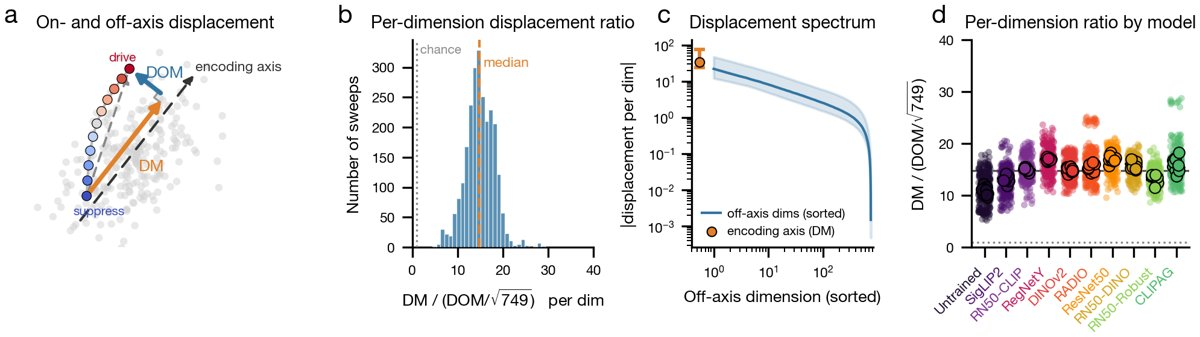

In [13]:
import io
from IPython.display import Image, display
from PIL import Image as PILImage

# A JPEG preview keeps the notebook small; open the PNG for full detail.
print(png)
im = PILImage.open(png).convert("RGB")
im.thumbnail((1200, 1200))
buf = io.BytesIO(); im.save(buf, "JPEG", quality=85, optimize=True)
display(Image(data=buf.getvalue(), format="jpeg", width=900))

**Supplementary Figure S9. Encoding-axis alignment of accentuation sweeps.** Each sweep's net latent displacement $d$ in the $750$-dimensional PCA feature space is decomposed into an on-axis component along the fitted encoding axis $\hat{a}$, $\mathrm{DM} = |d \cdot \hat{a}|$, and an off-axis residual over the remaining $749$ dimensions, $\mathrm{DOM} = \lVert d - (d\cdot\hat{a}) \hat{a} \rVert$. DM stands for directional modulation and DOM stands for direction-orthogonal modulation. Because DOM pools $749$ dimensions, alignment is quantified per representational dimension as $\mathrm{DM}/(\mathrm{DOM}/\sqrt{749})$. (A) We provide a schematic of the on- and off-axis decomposition in a toy-example latent space: an $11$-level accentuation sweep (blue "suppress" to red "drive") is split into its DM (orange) and DOM (blue) components. (B) Distributions of the per-dimension ratio across stimulus sweeps (orange dashed median $\approx 15$; gray dotted line at $x = 1$ marks the level where DM equals the root-mean-square (RMS) per-dimension off-axis displacement, $\mathrm{DM} = \mathrm{DOM}/\sqrt{749}$). $n = 2{,}500$ sweeps ($25$ sites $\times$ $10$ models $\times$ $10$ seed images). (C) In log-log space we show the distributions (over sweeps) of displacement either along the encoding axis (DM, orange point, median with IQR) or for the sorted off-axis dimensions (blue line, median with shaded IQR band); note that the displacement along the encoding axis is the single most-modulated dimension in $87.2%$ of sweeps. (D) Per-dimension ratio by model, one column per model (dots jittered, colored by model, adversarially trained models in bold; large dots mark the $10$ seeds of a representative channel per model). Black-and-color median bars per model; gray dashed line is the overall median and gray dotted line marks the same $x = 1$ reference as in (B). Alignment sits uniformly well above this reference across all $10$ models (including the Untrained baseline) (median $\approx 15\times$ greater per-dimension displacement along the encoding axis than the root-mean-square (RMS) off-axis displacement per dimension).